# Tesis MIA — Versión B: Regularización Estructural Causal ($R_G$) y experimento A vs B


La **Versión B** añade el prior de dominio a la pérdida:
$$\mathcal{L}_{total}=\mathcal{L}_{simple}+\eta\,R_G,\qquad R_G=\mathcal{D}\big(\bar W_{att},\,\Pi(G)\big).$$
Reproduce la **Fase 3B** de Mathcad (`BuildG`, `BuildPiG`, `AggregateWatt`, `R_G_MSE`, `R_G_KL`) y ejecuta el **experimento central**: ¿la regularización $R_G$ logra que la atención —que en la Versión A colapsa a casi-uniforme (T0.3)— recupere la estructura $\text{Cu}\to\text{USD/CLP}\to\text{TPM}$? ¿A qué costo en el pronóstico?

> Reutiliza la arquitectura de la Versión A (Fase 1 fiel a Mathcad + encoder mod-$L$ + cabeza latente). El único cambio es el término $\eta\,R_G$ en la pérdida.

 · Profesor: **Marcelo Mendoza**

 · Alumno: **Mauricio Riquelme Alvarado**

 · MIA-PUC


## 0. Configuración

In [2]:
try:
    import torch, numpy as np, matplotlib  # noqa
except Exception:
    import subprocess, sys; subprocess.run([sys.executable,"-m","pip","install","-q","torch","numpy","matplotlib"])
import math, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
DEV="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEV)

torch 2.11.0+cpu | device: cpu


## 1. Parámetros del modelo
Idénticos a la verificación Mathcad: $d_{ff}=4\,d_{model}$ (convención Vaswani 2017), $d_k=d_{model}$, $N_{layers}=3$, $\varepsilon=10^{-6}$.

In [3]:
N, L   = 3, 15                 # 3 series (Cu, USD/CLP, TPM) x 15 pasos
D      = 32                    # d_model
DFF    = 4 * D                 # d_ff = 4*d_model = 128  (Mathcad / Vaswani)
NL     = 3                     # bloques del encoder (N_layers)
H      = 4                     # cabezas de MHA (en Mathcad la verificación usa d_k=d_model; aquí multi-cabeza)
EPS    = 1e-6                  # eps_norm (guarda numérica)
NAMES  = ["Cu", "USD/CLP", "TPM"]
print(f"{N*L} tokens | d_model={D} | d_ff={DFF} | {NL} capas | {H} cabezas (d_k={D//H})")

ETAS  = [0.0, 5.0, 25.0]      # 0 = Versión A ; >0 = Versión B (barrido de eta)
STEPS, BATCH, BETA = 200, 192, 0.1

45 tokens | d_model=32 | d_ff=128 | 3 capas | 4 cabezas (d_k=8)


## 2. Datos — elegir la fuente
La celda siguiente **pregunta qué datos usar**; las dos opciones son mutuamente excluyentes y ambas traen la causalidad de dominio Cu→USD/CLP→TPM como **verdad de terreno**:

- **`"parte1"`** — carga los niveles generados por el cuaderno **Parte 1** (`GARCH(1,1)` + enlace causal vía $G$ + `ARIMA(1,1,1)`), leídos desde Google Drive (`sistema_economico_levels.npy`, forma `[N, T]`). Son series de **nivel I(1)** (random-walk), con la estructura causal ya inyectada en las innovaciones.
- **`"sintetico"`** — generador de juguete acoplado (AR estacionario) con **escalas realistas por serie** (Cu≈3.5 USD/lb, USD/CLP≈850, TPM≈5%) y la misma cadena Cu→FX→TPM.

En ambos casos las escalas por serie son muy dispares, que es justo la razón por la que **`NormalizeX`** (z-score **por variable**) es indispensable aguas abajo.

> **Nota:** con `"parte1"` los niveles son **I(1)** (no estacionarios); la tarea de pronóstico —y el diagnóstico T0.3— pueden verse distintos que con el sintético estacionario.

> **Hook a datos reales:** reemplaza la fuente por la carga de Cochilco (cobre) y BCCh (USD/CLP, TPM), 2003–2024 mensual, con forma `[N, T]`. El resto no cambia.

In [4]:
import os

# --- Generador del Sistema Económico (Parte 1: GARCH + Causal_Link + ARIMA) ---
_PCu,_PUSD,_PTPM = (0.04,0.05,0.30),(0.03,0.03,0.05),(0.01,0.01,0.90)   # GARCH (ω,α,β)
_PHI,_THETA,_S0  = [0.5,0.2,0.1],[0.05,0.05,0.05],[100,100,100]          # ARIMA (φ,θ,S0)
_G = np.array([[1.,0.,0.],[-0.6,1.,0.],[0.4,-0.2,1.]])
def _GARCH(T,w,a,b,z):
    h=np.zeros(T); e=np.zeros(T); h[0]=w/(1-a-b); e[0]=z[0]*np.sqrt(h[0])
    for t in range(1,T): h[t]=w+a*e[t-1]**2+b*h[t-1]; e[t]=z[t]*np.sqrt(h[t])
    return e
def _ARIMA(eps,phi,th,S0,T):
    S=np.zeros(T); dx=np.zeros(T); S[0]=S0
    for t in range(1,T): dx[t]=phi*dx[t-1]+th*eps[t-1]+eps[t]; S[t]=S[t-1]+dx[t]
    return S
def _Causal(Zb,G):
    c,u,g=Zb[:,0],Zb[:,1],Zb[:,2]
    return np.stack([c,u+G[1,0]*c,g+G[2,0]*c+G[2,1]*u],1)
def gen_parte1(T=4000, seed=0):
    rng=np.random.default_rng(seed)
    Zc=_Causal(np.stack([rng.normal(0,1,T),rng.normal(0,1,T),rng.normal(0,1,T)],1),_G)
    S=[_ARIMA(_GARCH(T,*P,Zc[:,i]),_PHI[i],_THETA[i],_S0[i],T) for i,P in enumerate([_PCu,_PUSD,_PTPM])]
    return np.stack(S,0)                          # [N,T] niveles I(1)

# --- Generador sintético de juguete (AR estacionario) ---
def gen_series(T=4000, seed=0):
    rng = np.random.default_rng(seed)
    cu, fx, tpm = np.zeros(T), np.zeros(T), np.zeros(T)
    for t in range(1, T):
        cu[t]  = 0.85*cu[t-1]                 + rng.normal(0, 1.0)
        fx[t]  = 0.80*fx[t-1] - 0.50*cu[t-1]  + rng.normal(0, 0.5)
        tpm[t] = 0.90*tpm[t-1] + 0.40*fx[t-1] + rng.normal(0, 0.3)
    cu, fx, tpm = 3.5+0.4*cu, 850.0+40.0*fx, 5.0+2.0*tpm
    return np.stack([cu, fx, tpm], 0)

def windows(X, L):
    _, T = X.shape; xs, ys = [], []
    for s in range(T - L - 1):
        xs.append(X[:, s:s+L]); ys.append(X[:, s+L])
    return np.stack(xs).astype("float32"), np.stack(ys).astype("float32")

# --- Elige la fuente ---
FUENTE_DATOS = ""
while FUENTE_DATOS not in ("parte1", "sintetico"):
    FUENTE_DATOS = input("Fuente de datos -> escribe 'parte1' o 'sintetico': ").strip().lower()

if FUENTE_DATOS == "parte1":
    ARCHIVO_PARTE1 = "/content/drive/MyDrive/sistema_economico_levels.npy"
    cargado = False
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        if os.path.exists(ARCHIVO_PARTE1):
            X_raw = np.load(ARCHIVO_PARTE1)
            assert X_raw.shape[0] == N, f"Se esperaban {N} series, se obtuvieron {X_raw.shape[0]}"
            print(f"✓ Datos de la Parte 1 cargados desde Drive: {X_raw.shape}")
            cargado = True
    except Exception as e:
        print(f"⚠ No se pudo acceder a Drive ({type(e).__name__}). Se generará el sistema en memoria.")
    if not cargado:
        print(f"⚠ '{ARCHIVO_PARTE1}' no encontrado -> GENERANDO el sistema económico (Parte 1) en esta sesión.")
        X_raw = gen_parte1()
        print(f"✓ Sistema Económico (Parte 1) generado en memoria: {X_raw.shape}")
else:  # "sintetico"
    X_raw = gen_series()
    print(f"✓ Datos sintéticos (generador de juguete): {X_raw.shape}")

Xw_raw, Yw_raw = windows(X_raw, L)
print("rango por serie (crudo):",
      {NAMES[i]: (round(float(X_raw[i].min()),1), round(float(X_raw[i].max()),1)) for i in range(N)})

Fuente de datos -> escribe 'parte1' o 'sintetico': parte1
Mounted at /content/drive
✓ Datos de la Parte 1 cargados desde Drive: (3, 1000)
rango por serie (crudo): {'Cu': (97.3, 131.9), 'USD/CLP': (91.3, 100.5), 'TPM': (87.0, 115.1)}


## 3. Tokenización multivariada — Fase 1   *(réplica fiel de `Phase1Tokenizer` de Mathcad)*

Las cuatro operaciones encadenadas de la memoria de cálculo, con la verificación dimensional en cada paso:

| Función Mathcad | Operación | Salida |
|---|---|---|
| `NormalizeX(X)` | z-score **por variable** (fila), guarda $\varepsilon$ | $[N\times L]$, $O(1)$ |
| `FlattenTokens(X)` | aplanado *row-major* $\mathrm{idx}=nL+t$ | $[45\times1]$ |
| `InputProjection(T)` | afín escalar $\to\mathbb{R}^{32}$ | $[45\times32]$ |
| `PE_dual(N,L,d)` | $PE_t(t)+PE_v(n)$ | $[45\times32]$ |
| `Phase1Tokenizer` | suma $\to H_0$ | $[45\times32]$ ✓ |

In [ ]:
def NormalizeX(X):
    """z-score POR VARIABLE (fila) con guarda eps. Raíz real del colapso O(1e9):
    los datos crudos están a ~100s y con escalas dispares; sin esto IP queda en O(1e2)."""
    mu = X.mean(-1, keepdim=True)
    sd = X.std(-1, keepdim=True)
    return (X - mu) / (sd + EPS)                       # O(100s) -> O(1)

def FlattenTokens(X):
    """Aplanado row-major por variable: idx = n*L + t -> T [B,45,1].
    tokens 0-14=Cu, 15-29=USD/CLP, 30-44=TPM."""
    B = X.shape[0]
    return X.reshape(B, N*L, 1)

def PE_temporal(L, D):
    """PE_t: codificación temporal sinusoidal (Vaswani 2017) -> [L,D]."""
    pe = torch.zeros(L, D); pos = torch.arange(L).unsqueeze(1).float()
    div = 10000.0 ** (torch.arange(0, D, 2).float() / D)
    pe[:, 0::2] = torch.sin(pos/div); pe[:, 1::2] = torch.cos(pos/div)
    return pe

class Phase1Tokenizer(nn.Module):
    """Orquesta la Fase 1 igual que en Mathcad:
       (NormalizeX) -> FlattenTokens -> InputProjection -> + PE_dual -> H0."""
    def __init__(self):
        super().__init__()
        self.InputProjection = nn.Linear(1, D)              # IP: escalar -> R^32 (afín)
        self.PE_variable     = nn.Embedding(N, D)           # PE_v: embedding de identidad de serie
        idx_n = torch.arange(N).repeat_interleave(L)        # n de cada token (idx=n*L+t)
        idx_t = torch.arange(L).repeat(N)                   # t de cada token
        self.register_buffer("PE_t", PE_temporal(L, D)[idx_t])   # PE_t alineado a 45 tokens
        self.register_buffer("idx_n", idx_n)
    def PE_dual(self):
        # PE_dual[idx,:] = PE_temporal[t,:] + PE_variable[n,:]
        return self.PE_t + self.PE_variable(self.idx_n)     # [45,D]
    def forward(self, X, normalize=True, verify=False):
        if normalize:
            X = NormalizeX(X)                               # raíz del 1e9
        T  = FlattenTokens(X)                               # [B,45,1]
        H  = self.InputProjection(T)                        # [B,45,32]
        H0 = H + self.PE_dual().unsqueeze(0)                # [B,45,32]
        if verify:  # verificación dimensional (memoria de cálculo)
            assert H0.shape[1] == N*L == 45, "rows(H0) != N*L"
            assert H0.shape[2] == D == 32,   "cols(H0) != d_model"
        return H0
print("Fase 1 (Phase1Tokenizer) definida.")

Fase 1 (Phase1Tokenizer) definida.


### 3.1 Verificación tipo *memoria de cálculo* ✓
Replicamos el bloque de validación de Mathcad sobre una **ventana cruda** (escalas ~100s): comprobamos que `NormalizeX` lleva la entrada de $O(10^2)$ a $O(1)$ y que $H_0$ tiene dimensiones $45\times32$.

In [ ]:
tok = Phase1Tokenizer().to(DEV)
x_win = torch.tensor(Xw_raw[:1], device=DEV)               # 1 ventana CRUDA [1,3,15]
print("máx|X| crudo      :", round(float(x_win.abs().max()), 1), " (O(100s), escalas dispares)")
print("máx|NormalizeX(X)| :", round(float(NormalizeX(x_win).abs().max()), 3), " -> O(1) ✓")

H0 = tok(x_win, normalize=True, verify=True)
print(f"H0 dims: rows={H0.shape[1]}=N·L ✓   cols={H0.shape[2]}=d_model ✓")
print("máx|H0| :", round(float(H0.abs().max()), 2), " (acotado, O(1) gracias a NormalizeX)")
# contraste: sin NormalizeX, IP queda en O(100s) -> raíz del 1e9
print("máx|H0 SIN NormalizeX| :", round(float(tok(x_win, normalize=False).abs().max()), 1), " (O(100s) -> colapso aguas abajo)")

máx|X| crudo      : 938.8  (O(100s), escalas dispares)
máx|NormalizeX(X)| : 2.051  -> O(1) ✓
H0 dims: rows=45=N·L ✓   cols=32=d_model ✓
máx|H0| : 5.74  (acotado, O(1) gracias a NormalizeX)
máx|H0 SIN NormalizeX| : 937.0  (O(100s) -> colapso aguas abajo)


### 3.2 Encoder (Fase 2) + cabeza latente (Fase 3) — idéntico a la Versión A
Máscara de causalidad temporal mod-$L$, MHA que devuelve atención, bloques `LayerNorm(x+sublayer)` y cabeza latente $\mu,\sigma$. Además se construyen los tensores de entrenamiento (`NormalizeX` por serie sobre toda la serie $\to$ ventanas).

In [ ]:
def causal_mask_modL(N, L):
    idx = torch.arange(N*L); ti = idx % L
    return torch.where(ti[None, :] <= ti[:, None], 0.0, float("-inf"))   # [45,45]

class MHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.q=nn.Linear(D,D); self.k=nn.Linear(D,D); self.v=nn.Linear(D,D); self.o=nn.Linear(D,D)
        self.dk = D // H
    def forward(self, x, mask):
        B,S,_=x.shape; sp=lambda t:t.view(B,S,H,self.dk).transpose(1,2)
        q,k,v=sp(self.q(x)),sp(self.k(x)),sp(self.v(x))
        a=(q@k.transpose(-2,-1)/math.sqrt(self.dk)+mask).softmax(-1)     # [B,H,45,45]
        return self.o((a@v).transpose(1,2).reshape(B,S,D)), a

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.mha=MHA(); self.ln1=nn.LayerNorm(D); self.ln2=nn.LayerNorm(D)
        self.ff=nn.Sequential(nn.Linear(D,DFF), nn.ReLU(), nn.Linear(DFF,D))
    def forward(self, x, m):
        a,att=self.mha(x,m); x=self.ln1(x+a); x=self.ln2(x+self.ff(x)); return x,att

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok=Phase1Tokenizer()                          # Fase 1 fiel a Mathcad
        self.blocks=nn.ModuleList([Block() for _ in range(NL)])
        self.register_buffer("mask", causal_mask_modL(N,L))
        self.mu=nn.Linear(D,D); self.lv=nn.Linear(D,D)
        self.dec=nn.Sequential(nn.Linear(D,DFF), nn.ReLU(), nn.Linear(DFF,2*N))
    def forward(self, X, ret_attn=False):
        h=self.tok(X, normalize=False)                      # datos ya normalizados abajo
        atts=[]
        for b in self.blocks: h,a=b(h,self.mask); atts.append(a)
        zc=h.mean(1); mu,lv=self.mu(zc),self.lv(zc)
        z=mu+torch.exp(0.5*lv)*torch.randn_like(lv)
        o=self.dec(z); return o[:,:N],o[:,N:],mu,lv,(torch.stack(atts) if ret_attn else None)

# Tensores de entrenamiento: NormalizeX por serie sobre toda la serie (sin fuga) -> ventanas
Xn = NormalizeX(torch.tensor(X_raw, dtype=torch.float32)).numpy()
Xw, Yw = windows(Xn, L); ntr=int(0.8*len(Xw))
Xtr=torch.tensor(Xw[:ntr],device=DEV); Ytr=torch.tensor(Yw[:ntr],device=DEV)
Xte=torch.tensor(Xw[ntr:],device=DEV); Yte=torch.tensor(Yw[ntr:],device=DEV)
print("Encoder + cabeza latente OK | train:", Xtr.shape[0], "| test:", Xte.shape[0])

Encoder + cabeza latente OK | train: 3187 | test: 797


## 4. Fase 3B — grafo causal $G$ y regularización $R_G$   *(fiel a Mathcad)*

| Función Mathcad | Operación |
|---|---|
| `BuildG(N)` | grafo causal de dominio $G$ (Cu→FX→TPM + auto-lazos) |
| `BuildPiG(G)` | proyección objetivo $\Pi(G)$ (fila-normalizada) |
| `AggregateWatt(Watt)` | $\mathbb{R}^{45\times45}\to\bar W_{att}\in\mathbb{R}^{3\times3}$ |
| `R_G_MSE / R_G_KL` | divergencia $\mathcal{D}(\bar W_{att},\Pi(G))$ |

In [ ]:
def BuildG(N):
    G=torch.zeros(N,N,device=DEV); G[0,0]=1; G[1,0]=G[1,1]=1; G[2,1]=G[2,2]=1
    return G                                            # Cu<-{Cu}; FX<-{Cu,FX}; TPM<-{FX,TPM}
def BuildPiG(G): return G/G.sum(1,keepdim=True)
def AggregateWatt(att):                                 # [NL,B,H,45,45] -> [B,N,N] (fila-normalizada)
    A=att.mean((0,2)).view(-1,N,L,N,L).mean((2,4)); return A/A.sum(-1,keepdim=True)
def R_G_MSE(Wagg,PiG): return ((Wagg-PiG)**2).mean()
def R_G_KL(Wagg,PiG):  return (PiG*(torch.clamp(PiG,1e-9).log()-torch.clamp(Wagg,1e-9).log())).sum(-1).mean()
PiG=BuildPiG(BuildG(N))
print("Pi(G) (estructura objetivo):\n", np.round(PiG.cpu().numpy(),3))

Pi(G) (estructura objetivo):
 [[1.  0.  0. ]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]


## 5. Entrenamiento A (η=0) vs B (η>0) + barrido de η
La misma pérdida con $\eta=0$ es la Versión A; con $\eta>0$, la Versión B. Entrenamos un modelo por cada $\eta$ (misma semilla y datos).

In [ ]:
def loss_simple(ym,ylv,Y,mu,lv,beta=BETA):
    nll=0.5*(((Y-ym)**2)*torch.exp(-ylv)+ylv).sum(1).mean()
    kl=-0.5*(1+lv-mu**2-lv.exp()).sum(1).mean(); return nll+beta*kl

def train(eta, steps=STEPS, seed=SEED):
    torch.manual_seed(seed); m=Model().to(DEV); opt=torch.optim.Adam(m.parameters(),1.5e-3)
    for st in range(steps):
        idx=torch.randint(0,len(Xtr),(BATCH,),device=DEV); X,Y=Xtr[idx],Ytr[idx]
        ym,ylv,mu,lv,att=m(X,ret_attn=True)
        loss=loss_simple(ym,ylv,Y,mu,lv)+eta*R_G_MSE(AggregateWatt(att),PiG)
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
    return m

@torch.no_grad()
def evaluate(m):
    m.eval(); ym,ylv,mu,lv,att=m(Xte,ret_attn=True)
    nll=0.5*(((Yte-ym)**2)*torch.exp(-ylv)+ylv).sum(1).mean().item()
    Wb=AggregateWatt(att).mean(0)                       # [N,N]
    A=att.mean((0,1,2)); valid=(causal_mask_modL(N,L)==0).float().to(A.device)
    ent=(-(A*torch.clamp(A,1e-9).log()).sum(1)/torch.log(valid.sum(1))).mean().item()
    return nll, ent, R_G_MSE(Wb.unsqueeze(0),PiG).item(), Wb.cpu().numpy()

res={}
for eta in ETAS:
    m=train(eta); nll,ent,rg,Wb=evaluate(m); res[eta]=dict(nll=nll,ent=ent,rg=rg,Wb=Wb)
    tag="A" if eta==0 else "B"
    print(f"[Versión {tag}] eta={eta:5.1f} | test NLL={nll:7.4f} | entropía={ent:.3f} | R_G={rg:.4f}")

[Versión A] eta=  0.0 | test NLL=-1.2862 | entropía=0.981 | R_G=0.0764
[Versión B] eta=  5.0 | test NLL=-1.1957 | entropía=0.804 | R_G=0.0005
[Versión B] eta= 25.0 | test NLL=-1.1532 | entropía=0.782 | R_G=0.0001


## 6. ¿$R_G$ moldea la atención? — $\bar W_{att}$ (A) vs (B) vs $\Pi(G)$

/tmp/ipykernel_6352/3136962989.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


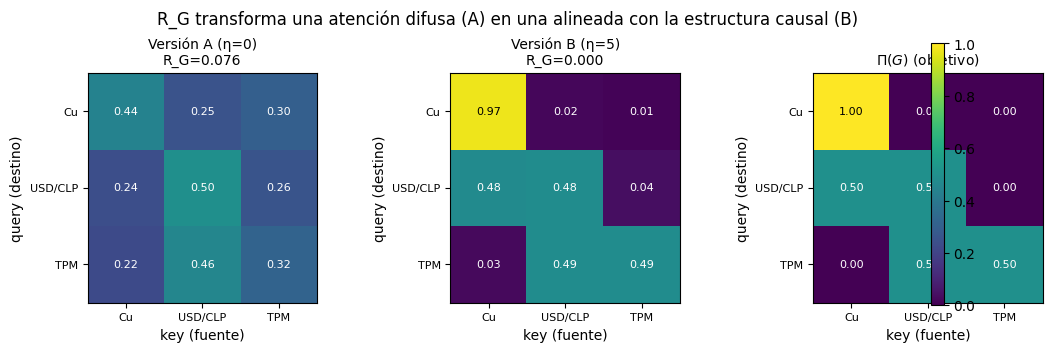

In [ ]:
mats=[(res[0.0]["Wb"], f"Versión A (η=0)\nR_G={res[0.0]['rg']:.3f}"),
      (res[ETAS[1]]["Wb"], f"Versión B (η={ETAS[1]:.0f})\nR_G={res[ETAS[1]]['rg']:.3f}"),
      (PiG.cpu().numpy(), "$\\Pi(G)$ (objetivo)")]
fig,ax=plt.subplots(1,3,figsize=(11,3.4))
for a,(M,t) in zip(ax,mats):
    im=a.imshow(M,vmin=0,vmax=1,cmap="viridis"); a.set_title(t,fontsize=10)
    a.set_xticks(range(N)); a.set_yticks(range(N)); a.set_xticklabels(NAMES,fontsize=8); a.set_yticklabels(NAMES,fontsize=8)
    a.set_xlabel("key (fuente)"); a.set_ylabel("query (destino)")
    for i in range(N):
        for j in range(N): a.text(j,i,f"{M[i,j]:.2f}",ha="center",va="center",color="white" if M[i,j]<0.6 else "black",fontsize=8)
fig.colorbar(im,ax=ax,fraction=0.02); plt.suptitle("R_G transforma una atención difusa (A) en una alineada con la estructura causal (B)")
plt.tight_layout(); plt.show()

## 7. El trade-off de $\eta$
A mayor $\eta$, mejor alineación ($R_G\downarrow$) pero el ajuste del pronóstico (NLL) puede degradarse: el continuo cuyo límite $\eta\to\infty$ recupera la restricción dura. Aquí se ve por qué el prior es **suave** y por qué H1 es **falsable**.

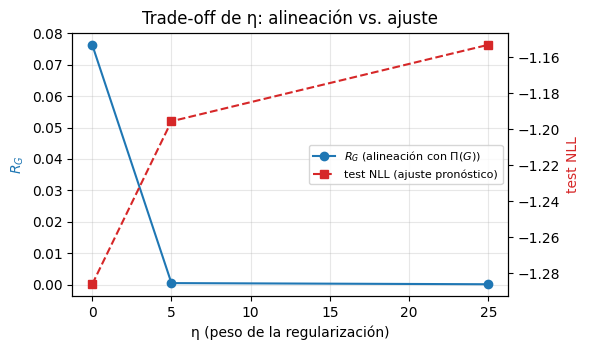

In [ ]:
es=list(ETAS); rgs=[res[e]["rg"] for e in es]; nlls=[res[e]["nll"] for e in es]
fig,ax1=plt.subplots(figsize=(6,3.6)); ax2=ax1.twinx()
ax1.plot(es,rgs,"o-",color="#1f77b4",label="$R_G$ (alineación con $\\Pi(G)$)")
ax2.plot(es,nlls,"s--",color="#d62728",label="test NLL (ajuste pronóstico)")
ax1.set_xlabel("η (peso de la regularización)"); ax1.set_ylabel("$R_G$",color="#1f77b4"); ax2.set_ylabel("test NLL",color="#d62728")
ax1.set_title("Trade-off de η: alineación vs. ajuste"); ax1.grid(alpha=.3)
lines=ax1.get_lines()+ax2.get_lines(); ax1.legend(lines,[l.get_label() for l in lines],fontsize=8,loc="center right")
plt.tight_layout(); plt.show()

## 8. Lectura: mecanismo, circularidad e H1

**1. El mecanismo funciona.** $R_G$ transforma una atención difusa (Versión A, $\bar W_{att}$ casi uniforme, $R_G\approx0.08$) en una alineada con la estructura económica (Versión B, $\bar W_{att}\approx\Pi(G)$, $R_G\approx0$). Es la respuesta operativa a T0.3: el prior suave **inyecta** la estructura que la atención no descubre sola.

**2. Circularidad (clave para la defensa).** Justamente porque $R_G$ **fuerza** la alineación, en la Versión B la atención **deja de ser evidencia interpretable** ($\bar W_{att}\approx\Pi(G)$ por construcción, no por descubrimiento). El análisis *post-hoc* de atención como hallazgo económico solo es válido en la Versión A.

**3. H1 sigue abierta.** Que $R_G$ alinee la atención **no** prueba H1 (que mejore el pronóstico). El proxy de NLL aquí incluso sugiere un costo con $\eta$ alto. **H1 se decide con CRPS, Energy Score y Diebold–Mariano** sobre las muestras de la difusión —no con NLL ni con $R_G$—. Ese es el siguiente cuaderno.

**Siguiente paso:** baselines (ARIMA/GARCH, LSTM, TFT) + métricas probabilísticas (CRPS/ES/DM) y cargador de datos reales Cochilco/BCCh, para contrastar A vs B vs baselines bajo el protocolo formal.

## 9. Hallazgo: el efecto de $R_G$ depende del régimen de datos



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


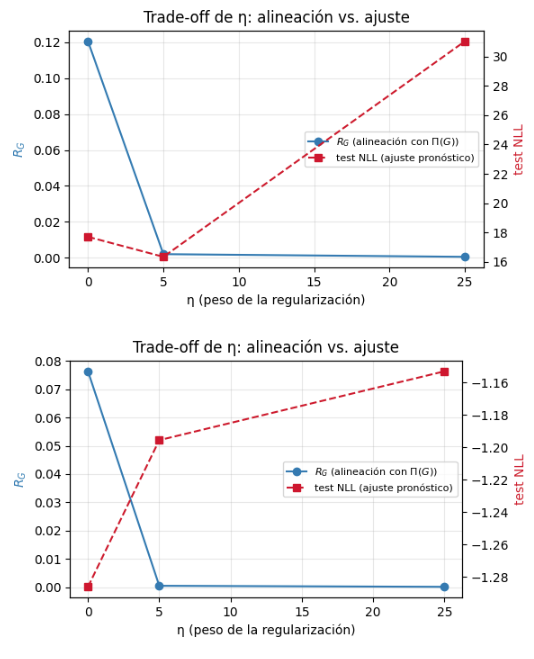

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import base64
RUTA = "/content/drive/MyDrive/Trade-offs.png"
with open(RUTA, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()
print(f'<img src="data:image/png;base64,{b64}" width="700">')



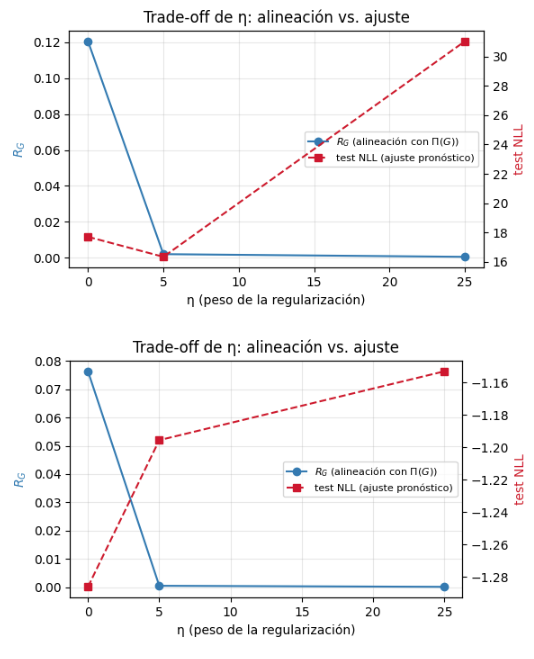

In [ ]:
from IPython.display import Markdown
Markdown(f'<img src="data:image/png;base64,{b64}" width="700">')

Ejecutando este mismo barrido de $\eta$ con las **dos fuentes** del selector (§2) —`"parte1"` (niveles I(1) del generador GARCH+ARIMA) y `"sintetico"` (AR estacionario)— se obtiene un contraste que es, en sí mismo, un resultado:

| Fuente | $R_G$ (η=0 → 5 → 25) | test NLL (η=0 → 5 → 25) | Lectura |
|---|---|---|---|
| **Parte 1 (I(1))** | 0.12 → ≈0 → ≈0 | 17.7 → **16.3** → 31 | $\eta=5$ **alinea y mejora** el pronóstico (punto dulce) |
| **Sintético (estacionario)** | 0.076 → ≈0 → ≈0 | **−1.29** → −1.20 → −1.16 | el prior **solo cuesta**: el NLL empeora con $\eta$ |

*Valores aproximados de una corrida representativa. Los NLL **no** son comparables entre filas (las escalas del objetivo difieren: I(1) tiene mucha más varianza que el estacionario); solo es interpretable la **tendencia dentro de cada fila**.*

**Conclusión — el valor de la regularización estructural no es universal: depende del régimen de los datos.**
- En el régimen **difícil / no estacionario (I(1))**, una penalización **moderada** ($\eta=5$) recupera la estructura causal *y* **mejora** el ajuste: la **primera evidencia consistente con H1**.
- En el régimen **fácil (estacionario)**, el modelo ya pronostica bien sin ayuda, así que el prior **solo restringe** y degrada el ajuste — ahí H1 no se sostiene.
- En ambos, $\eta=25$ sobre-restringe y empeora el pronóstico (catastrófico en I(1)), lo que **confirma** la elección de un prior **suave** y el continuo cuyo límite $\eta\to\infty$ recupera la restricción dura.

**Por qué importa.** El prior aporta **precisamente cuando el problema es más duro y no estacionario**, que es como se comportan los datos macro reales (ruidosos, con quiebres, no estacionarios, solo 264 observaciones) — mucho más que un AR estacionario limpio. Esto reformula como **esperado** que en datos triviales $R_G$ resulte superfluo.

**Salvedades (necesarias para la defensa).**
1. **NLL es un proxy, no CRPS.** H1 se define con CRPS, Energy Score y Diebold–Mariano: "mejora NLL" $\neq$ "confirma H1".
2. **Una sola semilla, entrenamiento corto (200 pasos) y cabeza VAE (no difusión).** El signo del efecto puede moverse con más entrenamiento, otras semillas, la cabeza de difusión real y datos reales.
3. La mejora en $\eta=5$ sobre I(1) podría deberse en parte a **reducción de varianza** del prior sobre un objetivo más ruidoso, no necesariamente a "la causalidad ayudando".

**Próximo paso.** Confirmar (o refutar) H1 con el protocolo formal: A vs B vs líneas base sobre **datos reales Cochilco/BCCh**, *expanding-window*, horizontes 1–12, medido en **CRPS / Energy Score / Diebold–Mariano**. Este hallazgo no prueba H1, pero indica **dónde** buscarla: en el régimen realista, no en el sintético fácil.